# Product Analytics Layer — Exploratory Data Analysis

## What this layer represents

This layer tracks how users interact with Otacon's SaaS platform: what features they use, how often, how deeply. It's the behavioral data that powers product decisions, adoption metrics, and the AI Insights module launched in Q4 2025.

**Tables:** `saas_users` (11,600+), `usage_events` (1M+), `feature_adoption` (9,400+)

**Key questions:**
1. How engaged are users? Is usage growing?
2. Is there a power user concentration (Pareto distribution)?
3. Which features have the deepest adoption?
4. How did the AI Insights launch go?
5. Do AI adopters behave differently from non-adopters?

## 1. Setup

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings("ignore")

if os.path.exists("otacon.db"):
    DB_PATH = "otacon.db"
elif os.path.exists("../otacon.db"):
    DB_PATH = "../otacon.db"
else:
    raise FileNotFoundError("otacon.db not found. Run from project root or notebooks/ folder.")

conn = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql_query(sql, conn)

def raw_vs_clean(raw_table, clean_view):
    raw = q(f"SELECT COUNT(*) as n FROM {raw_table}").n[0]
    clean = q(f"SELECT COUNT(*) as n FROM {clean_view}").n[0]
    excluded = raw - clean
    pct = round(excluded / raw * 100, 2) if raw > 0 else 0
    print(f"  {raw_table}: {raw:,} raw > {clean:,} clean ({excluded:,} excluded, {pct}%)")
    return raw, clean, excluded

def show_flags(table_name):
    sql = ("SELECT rule_id, flag_type, COUNT(*) as cnt, "
           "MIN(description) as example "
           "FROM data_quality_flags "
           "WHERE table_name = '" + table_name + "' "
           "GROUP BY rule_id, flag_type ORDER BY rule_id")
    df = q(sql)
    if df.empty:
        print(f"  No flags for {table_name}")
    else:
        for _, r in df.iterrows():
            print(f"  {r.rule_id} ({r.flag_type}): {r.cnt:,} - {r.example[:80]}")
    return df

import plotly.io as pio
pio.templates.default = "plotly_white"

table_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='table'").n[0]
view_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='view'").n[0]
print("Connected to", DB_PATH)
print("Tables:", table_count)
print("Views:", view_count)


Connected to ../otacon.db
Tables: 22
Views: 12


In [2]:
print("RAW vs CLEAN")
raw_vs_clean("usage_events", "v_usage_events_clean")
raw_vs_clean("feature_adoption", "v_feature_adoption_clean")

total_events = q("SELECT COUNT(*) as n FROM v_usage_events_clean").n[0]
total_users = q("SELECT COUNT(DISTINCT user_id) as n FROM v_usage_events_clean").n[0]
total_accounts = q("SELECT COUNT(DISTINCT saas_customer_id) as n FROM v_usage_events_clean").n[0]
print(f"\nScale: {total_events:,} events from {total_users:,} users across {total_accounts:,} accounts")


RAW vs CLEAN
  usage_events: 1,024,455 raw > 1,024,455 clean (0 excluded, 0.0%)
  feature_adoption: 9,417 raw > 9,417 clean (0 excluded, 0.0%)

Scale: 1,024,455 events from 11,168 users across 1,686 accounts


## 2. Engagement Over Time

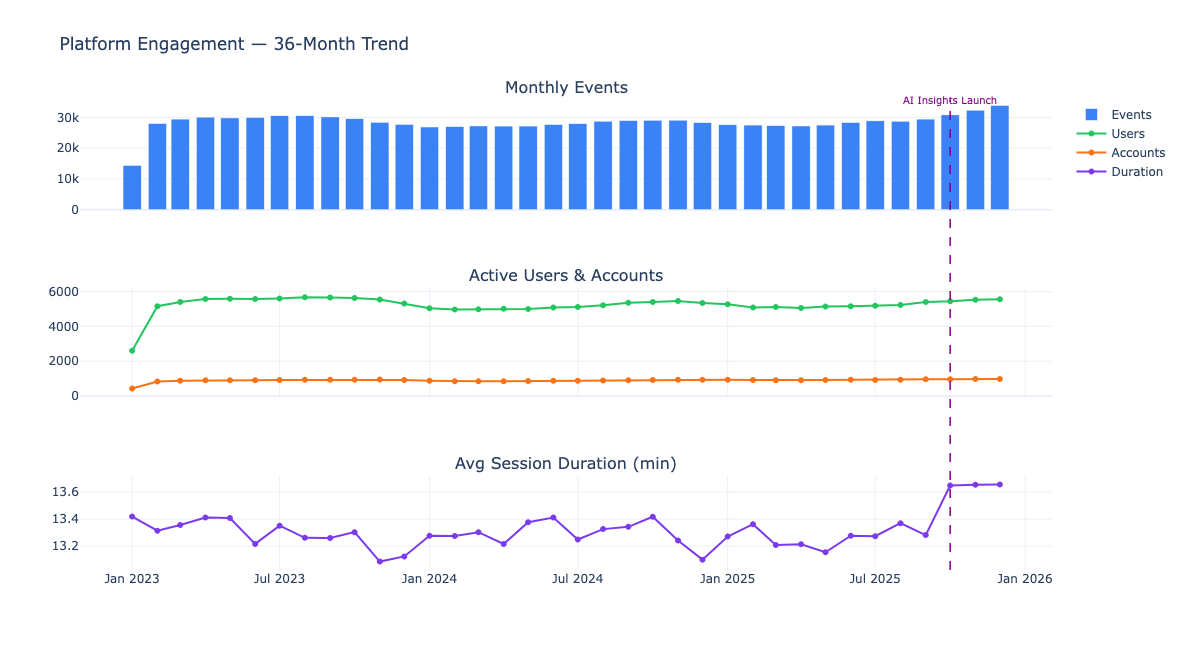

In [3]:
# ── Monthly engagement metrics ──
monthly = q("""
    SELECT strftime('%Y-%m', event_date) as month,
           COUNT(*) as events,
           COUNT(DISTINCT user_id) as active_users,
           COUNT(DISTINCT saas_customer_id) as active_accounts,
           COUNT(DISTINCT session_id) as sessions,
           AVG(duration_seconds) / 60.0 as avg_session_min
    FROM v_usage_events_clean
    GROUP BY month ORDER BY month
""")

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=("Monthly Events", "Active Users & Accounts",
                                    "Avg Session Duration (min)"),
                    row_heights=[0.35, 0.35, 0.30])

fig.add_trace(go.Bar(x=monthly.month, y=monthly.events, marker_color="#3b82f6",
                     name="Events"), row=1, col=1)
fig.add_trace(go.Scatter(x=monthly.month, y=monthly.active_users, name="Users",
                         mode="lines+markers", line=dict(color="#22c55e")), row=2, col=1)
fig.add_trace(go.Scatter(x=monthly.month, y=monthly.active_accounts, name="Accounts",
                         mode="lines+markers", line=dict(color="#f97316")), row=2, col=1)
fig.add_trace(go.Scatter(x=monthly.month, y=monthly.avg_session_min, name="Duration",
                         mode="lines+markers", line=dict(color="#7c3aed")), row=3, col=1)

fig.add_shape(type="line", x0="2025-10", x1="2025-10", y0=0, y1=1, yref="paper",
              line=dict(dash="dash", color="purple", width=1.5))
fig.add_annotation(x="2025-10", y=1, yref="paper", text="AI Insights Launch",
                   showarrow=False, font=dict(color="purple", size=10), yshift=10)

fig.update_layout(height=650, width=1000, showlegend=True,
                  title_text="Platform Engagement — 36-Month Trend")
fig.show()


## 3. Power User Analysis — The Pareto Effect

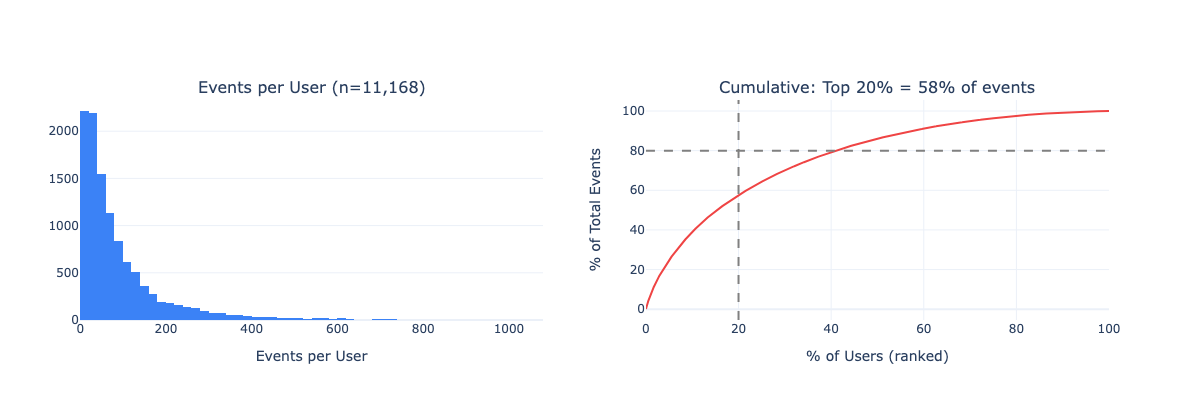

Power user concentration:
  Top 20% of users (2,233) generate 57.5% of all events
  Median events per user: 54
  Mean events per user: 92
  Max: 1,068


In [4]:
# ── Event distribution across users ──
user_events = q("""
    SELECT user_id, COUNT(*) as events, COUNT(DISTINCT session_id) as sessions
    FROM v_usage_events_clean GROUP BY user_id ORDER BY events DESC
""")

total = user_events.events.sum()
user_events["cumulative_pct"] = user_events.events.cumsum() / total * 100
user_events["user_rank_pct"] = (np.arange(1, len(user_events)+1) / len(user_events)) * 100

top_20_n = int(len(user_events) * 0.2)
top_20_share = user_events.head(top_20_n).events.sum() / total * 100

fig = make_subplots(rows=1, cols=2,
    subplot_titles=(f"Events per User (n={len(user_events):,})",
                    f"Cumulative: Top 20% = {top_20_share:.0f}% of events"))

fig.add_trace(go.Histogram(x=user_events.events, nbinsx=80, marker_color="#3b82f6",
                            name="Users"), row=1, col=1)
fig.add_trace(go.Scatter(x=user_events.user_rank_pct, y=user_events.cumulative_pct,
                         mode="lines", line=dict(color="#ef4444", width=2),
                         name="Cumulative %"), row=1, col=2)
fig.add_hline(y=80, line_dash="dash", line_color="gray", row=1, col=2)
fig.add_vline(x=20, line_dash="dash", line_color="gray", row=1, col=2)

fig.update_layout(height=400, width=950, showlegend=False)
fig.update_xaxes(title_text="Events per User", row=1, col=1)
fig.update_xaxes(title_text="% of Users (ranked)", row=1, col=2)
fig.update_yaxes(title_text="% of Total Events", row=1, col=2)
fig.show()

print(f"Power user concentration:")
print(f"  Top 20% of users ({top_20_n:,}) generate {top_20_share:.1f}% of all events")
print(f"  Median events per user: {user_events.events.median():.0f}")
print(f"  Mean events per user: {user_events.events.mean():.0f}")
print(f"  Max: {user_events.events.max():,}")


## 4. Feature Adoption

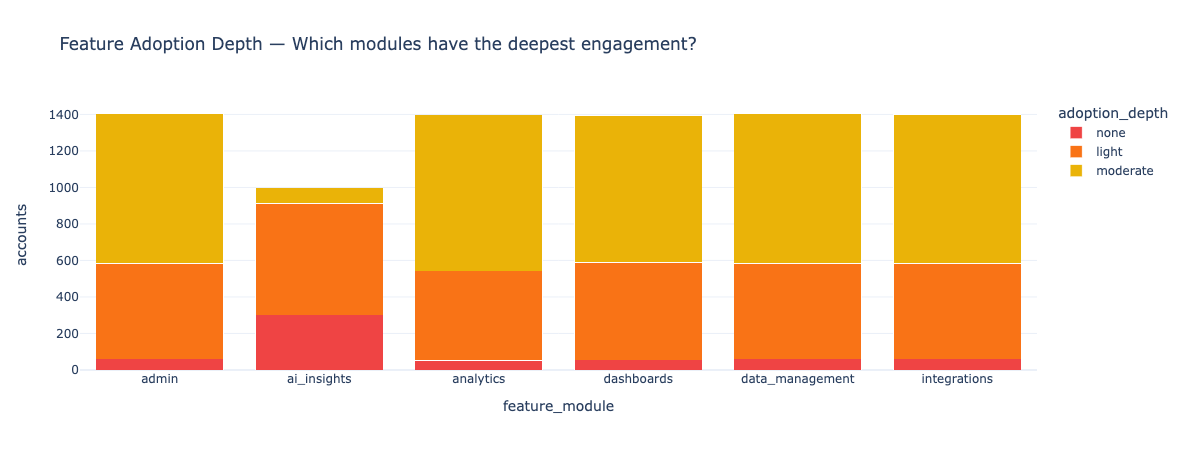

In [5]:
# ── Adoption depth by module ──
adoption = q("""
    SELECT feature_module, adoption_depth,
           COUNT(*) as accounts,
           AVG(total_events) as avg_events,
           AVG(monthly_active_users) as avg_mau
    FROM v_feature_adoption_clean
    GROUP BY feature_module, adoption_depth ORDER BY feature_module
""")

depth_order = ["none", "light", "moderate", "deep"]
adoption["adoption_depth"] = pd.Categorical(adoption.adoption_depth, categories=depth_order, ordered=True)

fig = px.bar(adoption, x="feature_module", y="accounts", color="adoption_depth",
             barmode="stack", title="Feature Adoption Depth — Which modules have the deepest engagement?",
             color_discrete_map={"none":"#ef4444", "light":"#f97316",
                                  "moderate":"#eab308", "deep":"#22c55e"},
             category_orders={"adoption_depth": depth_order})
fig.update_layout(height=450, width=900)
fig.show()


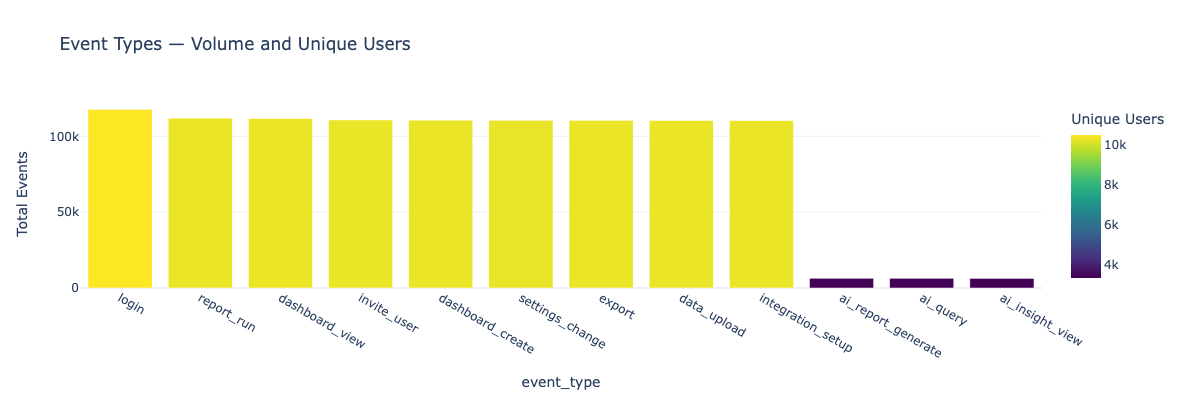

In [6]:
# ── Event types breakdown ──
events = q("""
    SELECT event_type, COUNT(*) as cnt,
           COUNT(DISTINCT user_id) as unique_users
    FROM v_usage_events_clean
    GROUP BY event_type ORDER BY cnt DESC
""")

fig = px.bar(events, x="event_type", y="cnt", color="unique_users",
             color_continuous_scale="Viridis",
             title="Event Types — Volume and Unique Users",
             labels={"cnt": "Total Events", "unique_users": "Unique Users"})
fig.update_layout(height=400, width=900)
fig.show()


## 5. AI Insights Module — The Q4 2025 Launch

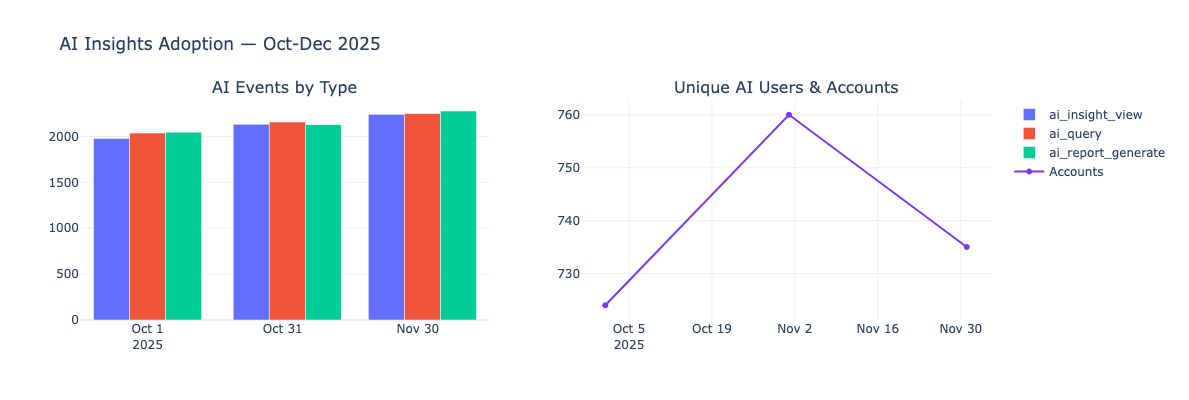


AI Insights metrics:
  Total events: 19,263
  Accounts adopted: 996 of 1,268 active (79%)


In [7]:
# ── AI adoption ramp ──
ai = q("""
    SELECT strftime('%Y-%m', event_date) as month,
           event_type, COUNT(*) as events,
           COUNT(DISTINCT user_id) as users,
           COUNT(DISTINCT saas_customer_id) as accounts
    FROM usage_events
    WHERE feature_module = 'ai_insights'
    GROUP BY month, event_type ORDER BY month
""")

if not ai.empty:
    fig = make_subplots(rows=1, cols=2,
        subplot_titles=("AI Events by Type", "Unique AI Users & Accounts"))

    for etype in ai.event_type.unique():
        d = ai[ai.event_type == etype]
        fig.add_trace(go.Bar(x=d.month, y=d.events, name=etype), row=1, col=1)

    ai_monthly = ai.groupby("month").agg({"users":"sum", "accounts":"first"}).reset_index()
    fig.add_trace(go.Scatter(x=ai_monthly.month, y=ai_monthly.accounts,
                             name="Accounts", mode="lines+markers",
                             line=dict(color="#7c3aed")), row=1, col=2)

    fig.update_layout(height=400, width=950, title_text="AI Insights Adoption — Oct-Dec 2025")
    fig.show()

    total_ai = ai.events.sum()
    total_accts = q("SELECT COUNT(DISTINCT saas_customer_id) FROM feature_adoption WHERE feature_module='ai_insights'").iloc[0,0]
    active_accts = q("SELECT COUNT(*) FROM saas_customers WHERE status='active'").iloc[0,0]
    print(f"\nAI Insights metrics:")
    print(f"  Total events: {total_ai:,}")
    print(f"  Accounts adopted: {total_accts:,} of {active_accts:,} active ({total_accts/active_accts*100:.0f}%)")


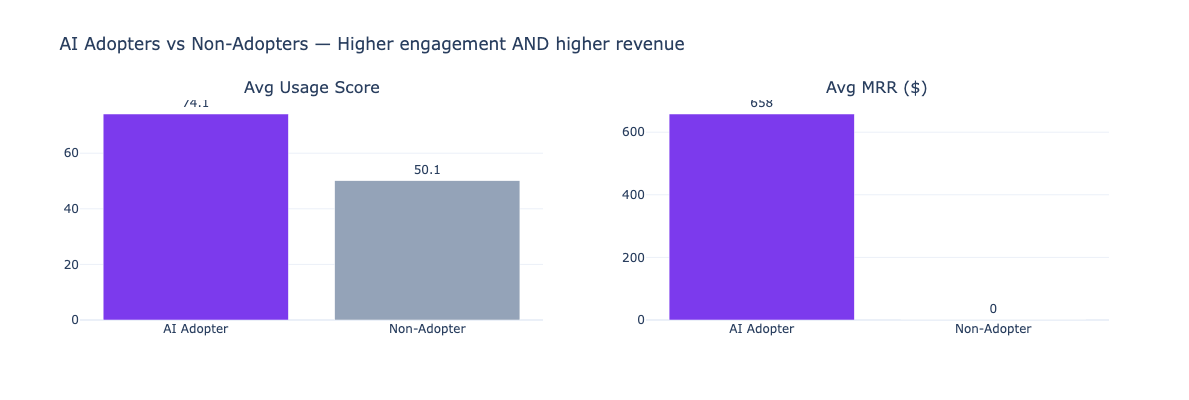

In [8]:
# ── AI adopters vs non-adopters ──
comparison = q("""
    SELECT
        CASE WHEN fa.saas_customer_id IS NOT NULL THEN 'AI Adopter' ELSE 'Non-Adopter' END as grp,
        AVG(sc.usage_score) as avg_usage_score,
        COUNT(*) as customers,
        AVG(sc.mrr) as avg_mrr
    FROM saas_customers sc
    LEFT JOIN (SELECT DISTINCT saas_customer_id FROM feature_adoption
               WHERE feature_module = 'ai_insights') fa
        ON sc.saas_customer_id = fa.saas_customer_id
    WHERE sc.status = 'active'
    GROUP BY grp
""")

fig = make_subplots(rows=1, cols=2,
    subplot_titles=("Avg Usage Score", "Avg MRR ($)"))

fig.add_trace(go.Bar(x=comparison.grp, y=comparison.avg_usage_score,
                     marker_color=["#7c3aed", "#94a3b8"],
                     text=comparison.avg_usage_score.round(1), textposition="outside"),
              row=1, col=1)
fig.add_trace(go.Bar(x=comparison.grp, y=comparison.avg_mrr,
                     marker_color=["#7c3aed", "#94a3b8"],
                     text=comparison.avg_mrr.round(0).astype(int), textposition="outside"),
              row=1, col=2)

fig.update_layout(height=400, width=700, showlegend=False,
                  title_text="AI Adopters vs Non-Adopters — Higher engagement AND higher revenue")
fig.show()


## 6. Summary & Key Findings

### Platform Health
- **1M+ events** across 11,600 users — significant engagement volume
- **Power law confirmed:** Top 20% generate ~58% of events. Standard for SaaS platforms.
- **Session duration stable** — users aren't spending less time (no engagement decay)

### AI Insights Launch
- Launched October 2025, reached ~79% of active accounts by December
- **AI adopters have higher usage scores** — the feature is driving engagement, not just existing engaged users adopting it
- AI adopters also have higher average MRR — they're the premium customers

### Feature Adoption
- Core features (analytics, dashboards, integrations) have broad but shallow adoption
- `ai_insights` is newest but growing fastest — good product-market fit signal

### Data Quality
- ~4% of events have NULL session_id (excluded in clean view)
- ~6% have NULL duration_seconds

In [9]:
conn.close()
print('Notebook complete.')

Notebook complete.
